Exploratory Data Analysis


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
%matplotlib inline



In [ ]:
# Load the datasets
train_data = pd.read_csv('../data/raw/Restaurants_Train_v2.csv')
test_data = pd.read_csv('../data/raw/Restaurants_Test_Data_PhaseA.csv') 

In [31]:
train_data.head()

,id,Sentence,Aspect Term,polarity,from,to,review_length
0,3121,But the staff was so horrible to us.,staff,negative,8,13,8
1,2777,"To be completely fair, the only redeeming fact...",food,positive,57,61,26
2,1634,"The food is uniformly exceptional, with a very...",food,positive,4,8,27
3,1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62,27
4,1634,"The food is uniformly exceptional, with a very...",menu,neutral,141,145,27


In [10]:
#train_data shape
train_data.shape


(3693, 6)

In [11]:
#test_data shape
test_data.shape

(800, 2)

In [12]:
train_data.columns #columns of train data


Index(['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to'], dtype='str')

In [13]:
test_data.columns #columns of test data

Index(['id', 'Sentence'], dtype='str')

In [15]:
train_data.dtypes #columns data types of train data


id             int64
Sentence         str
Aspect Term      str
polarity         str
from           int64
to             int64
dtype: object

In [16]:
test_data.dtypes #columns data types of test data

id          str
Sentence    str
dtype: object

In [17]:
train_data.isnull().sum() #check for null values in train data

id             0
Sentence       0
Aspect Term    0
polarity       0
from           0
to             0
dtype: int64

In [18]:
test_data.isnull().sum() #check for null values in test data

id          0
Sentence    0
dtype: int64

In [19]:
train_data.duplicated().sum() #check for duplicate values in train data

np.int64(0)

In [20]:
test_data.duplicated().sum() #check for duplicate values in test data

np.int64(0)

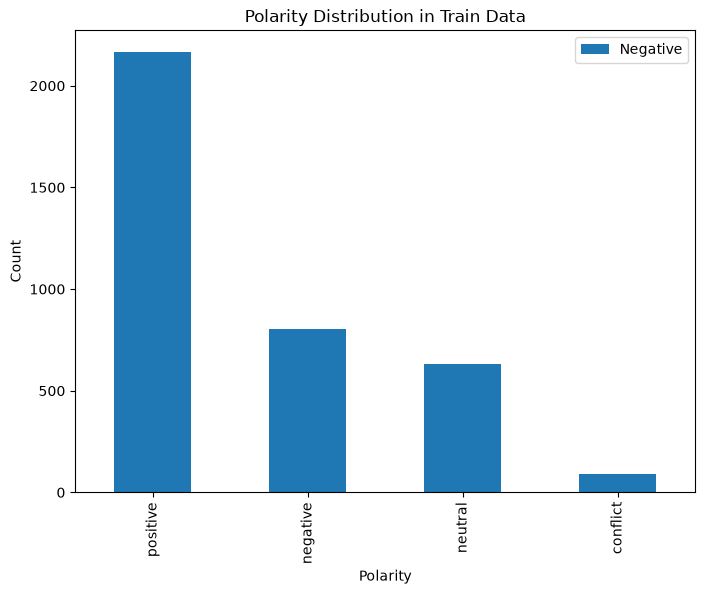

In [23]:
#polarity distribution in train data using bar chart
plt.figure(figsize=(8,6))
train_data['polarity'].value_counts().plot(kind='bar')
plt.title('Polarity Distribution in Train Data')
plt.xlabel('Polarity')
plt.ylabel('Count')
plt.legend(['Negative', 'Neutral', 'Positive'])
plt.show()


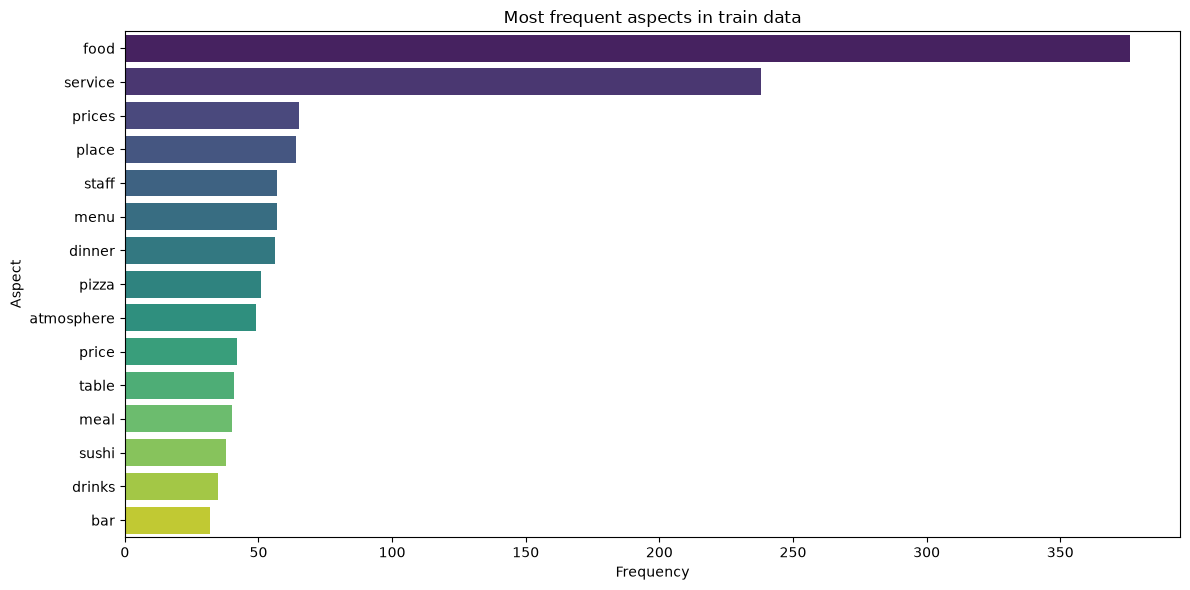

In [30]:
#aspect term distribution
aspect_counts = (
    train_data["Aspect Term"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .head(15)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=aspect_counts.values, y=aspect_counts.index, 
            hue=aspect_counts.index, palette="viridis", legend=False)
plt.title("Most frequent aspects in train data")
plt.xlabel("Frequency")
plt.ylabel("Aspect")
plt.tight_layout()
plt.show()

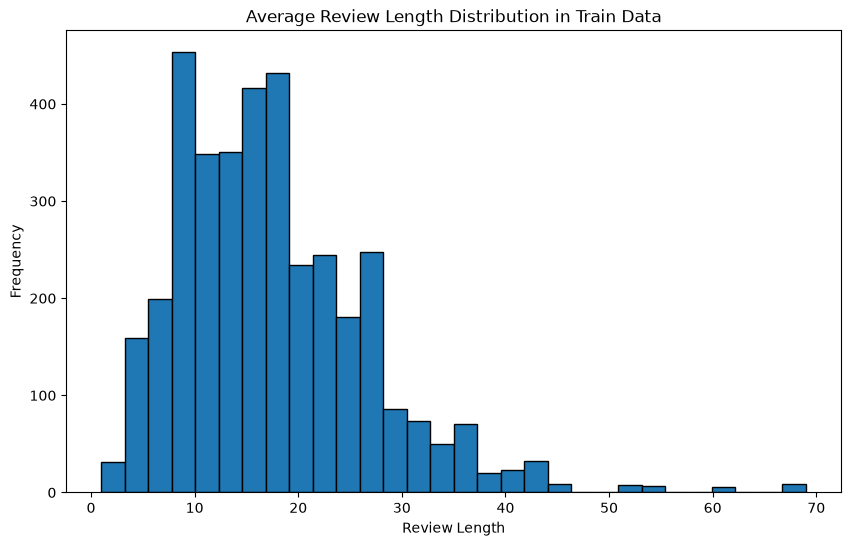

In [26]:
#average review length distribution in train data using histogram
train_data['review_length'] = train_data['Sentence'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10,6))
plt.hist(train_data['review_length'], bins=30, edgecolor='black')
plt.title('Average Review Length Distribution in Train Data')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

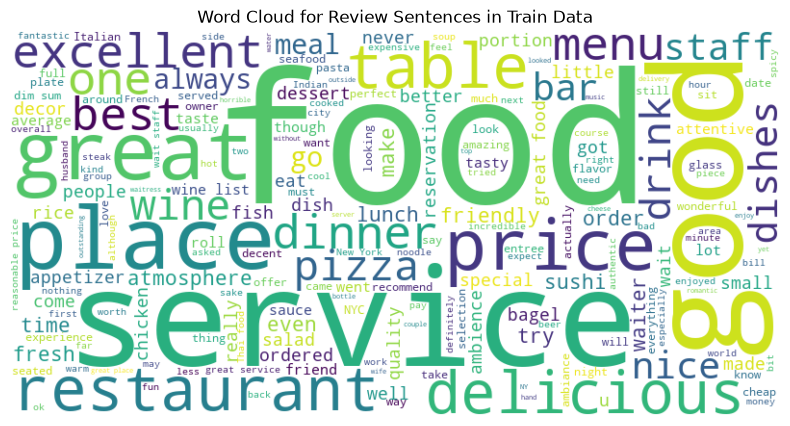

In [27]:
#Word cloud for the review sentences in train data


text = " ".join(train_data["Sentence"].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Sentences in Train Data")
plt.show()

In [29]:
len(wordcloud.words_)

200

1.After performing EDA , we can understand that train data has 6 columns and test data has 2 columns 
2.In train data , sentence ,aspect and polarity has string data
3.Train data doest has null or duplicated values
4.polarity distribution has one word conclusion for the review, maximum review are positive, some negative ,neutral and conflicts
5.The word cloud contains 200 unique words; most frequent terms include 'place', 'food', 'service', 'great' — confirming these are the dominant topics in restaurant reviews.
6.Review length varies from 100 to 400
7.We were also able to discover the most frequent aspects considering the review